In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

In [8]:
class GFETDiracProcessor:

    def __init__(
        self,
        folder_path,
        channels_to_omit,
        channel_colors,
        func_steps,
        analyte_steps,
        func_title,
        analyte_title
    ):

        self.folder_path = folder_path
        self.channels_to_plot = [i for i in range(16) if i not in channels_to_omit]
        if channel_colors:
            self.channel_colors = channel_colors
        else:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            first_16_colors = [colors[i % len(colors)] for i in range(16)]
            self.channel_colors = first_16_colors

        self.func_steps = func_steps
        self.analyte_steps = analyte_steps

        self.func_title = func_title
        self.analyte_title = analyte_title

        self.func_files = []
        self.analyte_files = []

    # -----------------------------
    # FILE GATHERING
    # -----------------------------

    def gather_files(self):

        self.func_files = []
        self.analyte_files = []

        for filename in sorted(os.listdir(self.folder_path)):

            if filename.startswith("analyte"):
                self.analyte_files.append(filename)

            elif filename.startswith("func"):
                print(filename)
                self.func_files.append(filename)

    # -----------------------------
    # TRANSCONDUCTANCE
    # -----------------------------

    def compute_transconductance(self, vg, idrain):

        slope = np.gradient(idrain, vg)

        # windowed average (size 7)
        kernel = np.ones(7) / 7
        slope = np.convolve(slope, kernel, mode="same")

        pos_idx = np.argmax(slope)
        neg_idx = np.argmin(slope)

        return vg[pos_idx], vg[neg_idx]

    # -----------------------------
    # DIRAC EXTRACTION
    # -----------------------------

    def extract_dirac(self, files):

        fwd = np.zeros((len(files), 16))
        rev = np.zeros((len(files), 16))

        for i, path in enumerate(files):

            df = pd.read_csv(self.folder_path + path)

            dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()]

            fwd_cols = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]
            rev_cols = [f"DIRAC_V_REV_CH{i}" for i in range(16)]

            for j, ch in enumerate(range(16)): # enumerate(self.channels_to_plot):

                fwd_vals = dirac_rows[fwd_cols[ch]].to_numpy()
                rev_vals = dirac_rows[rev_cols[ch]].to_numpy()

                fwd[i, j] = fwd_vals[-1]
                rev[i, j] = rev_vals[-1]

        return fwd, rev

    # -----------------------------
    # TRANSCONDUCTANCE EXTRACTION
    # -----------------------------

    def extract_transconductance(self, files):

        pos_trans = np.zeros((len(files), len(self.channels_to_plot)))
        neg_trans = np.zeros((len(files), len(self.channels_to_plot)))

        for i, path in enumerate(files):

            df = pd.read_csv(self.folder_path + path)

            last_sweep = int(df["SWEEP_IDX"].iloc[-1] - 1)

            for j, ch in enumerate(range(16)): # enumerate(self.channels_to_plot):

                subset = df.loc[
                    df["SWEEP_IDX"] == last_sweep,
                    ["V_GATE", f"I_CH{ch}"]
                ]

                vg = subset["V_GATE"].to_numpy()
                idrain = subset[f"I_CH{ch}"].to_numpy()

                pos, neg = self.compute_transconductance(vg, idrain)

                pos_trans[i, j] = pos
                neg_trans[i, j] = neg

        return pos_trans, neg_trans

    # -----------------------------
    # FUNCTIONALIZATION PLOTS
    # -----------------------------

    def plot_functionalization(self):

        self.gather_files()

        fwd, rev = self.extract_dirac(self.func_files)

        x = np.arange(len(self.func_files))

        for data, label in [(fwd, "Forward"), (rev, "Reverse")]:

            plt.figure(figsize=(7,4))

            for col in self.channels_to_plot: # range(data.shape[1]):

                plt.plot(
                    x,
                    data[:,col],
                    marker="o",
                    color = self.channel_colors[col],
                    label=f"CH {col}",
                )

            plt.xlabel("Functionalization Step")
            plt.ylabel("Dirac Voltage (V)")
            plt.xticks(x, self.func_steps[:len(self.func_files)])
            plt.grid(True)

            plt.legend(
                fontsize=9,
                loc="center left",
                bbox_to_anchor=(1.02,0.5)
            )

            plt.title(f"{self.func_title}, {label} Sweep")
            plt.tight_layout()
            plt.show()

    # -----------------------------
    # ANALYTE PLOTS
    # -----------------------------

    def plot_analyte_abs(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)

        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        x = np.arange(len(self.analyte_files))
    
        for data, label, baseline in [(fwd, "Forward", base_fwd), (rev, "Reverse", base_rev)]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
                
                plt.axhline(baseline[col], linestyle="--", color=self.channel_colors[col])

    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Voltage (V)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            baseline_line = Line2D([0], [0], color='black', linestyle='--', label='Baseline')
            handles, labels = plt.gca().get_legend_handles_labels()
            handles.append(baseline_line)
            plt.legend(handles=handles, fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"{self.analyte_title}, {label} Sweep")
            plt.tight_layout()
            plt.show()



            
    def plot_analyte_abs_change(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)
    
        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        delta_fwd = fwd - base_fwd
        delta_rev = rev - base_rev
    
        x = np.arange(len(self.analyte_files))
    
        for data, label in [(delta_fwd, "Forward"), (delta_rev, "Reverse")]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
    
            plt.axhline(0, linestyle="--", color='black', label='Baseline')  # baseline reference
    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Shift (V)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"{self.analyte_title} (Δ from baseline), {label}")
            plt.tight_layout()
            plt.show()

    
    def plot_analyte_norm(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)
    
        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        norm_fwd = (fwd - base_fwd) / base_fwd * 100
        norm_rev = (rev - base_rev) / base_rev * 100
    
        x = np.arange(len(self.analyte_files))
    
        for data, label in [(norm_fwd, "Forward"), (norm_rev, "Reverse")]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
    
            plt.axhline(0, linestyle="--", color='black', label='Baseline')
    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Shift (%)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"Normalized {self.analyte_title}, {label}")
            plt.tight_layout()
            plt.show()


func1-w7d16-initial.csv


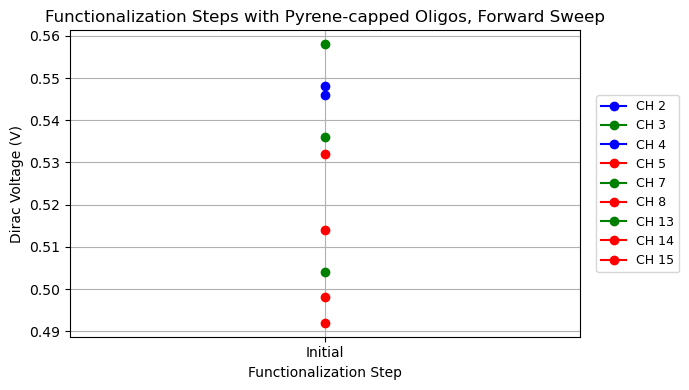

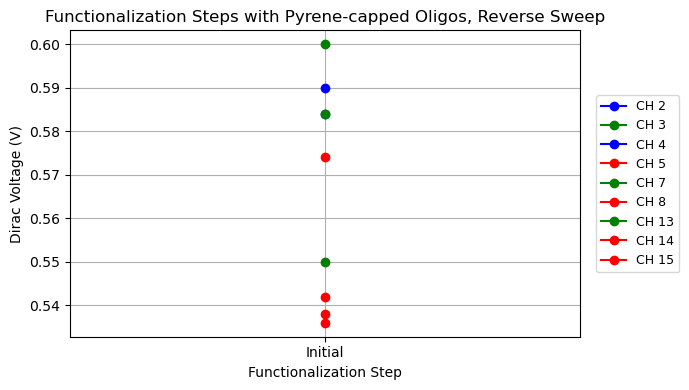

func1-w7d16-initial.csv


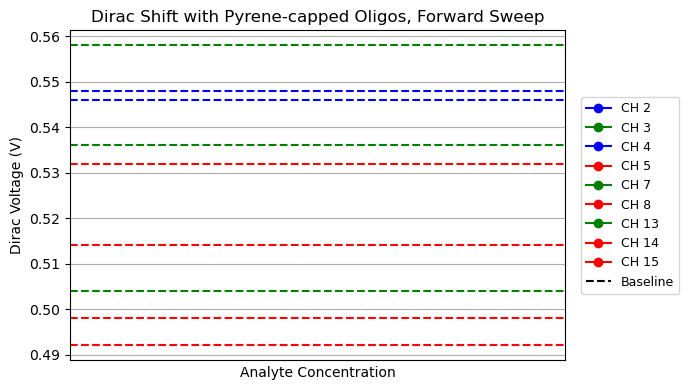

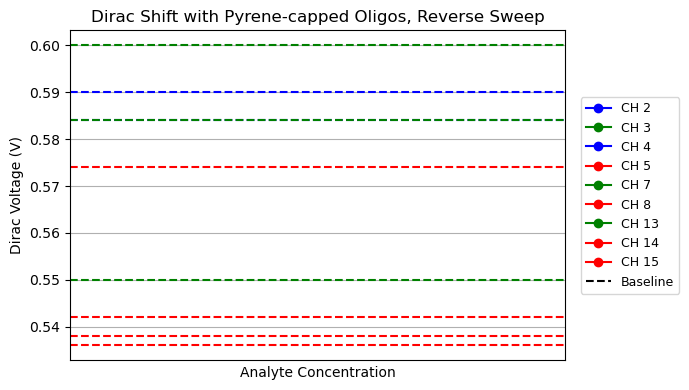

func1-w7d16-initial.csv


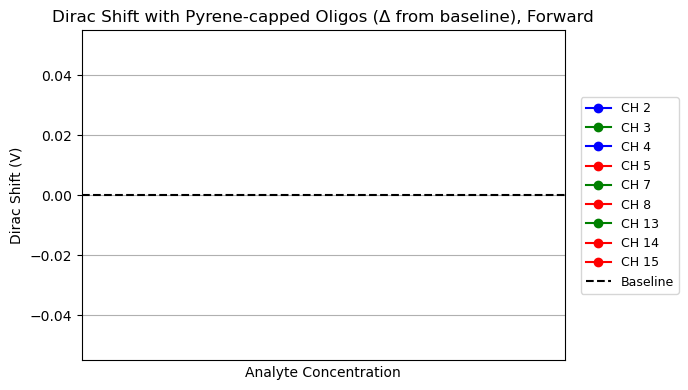

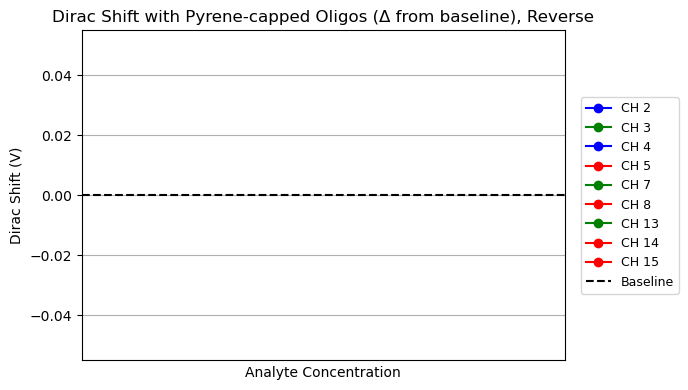

func1-w7d16-initial.csv


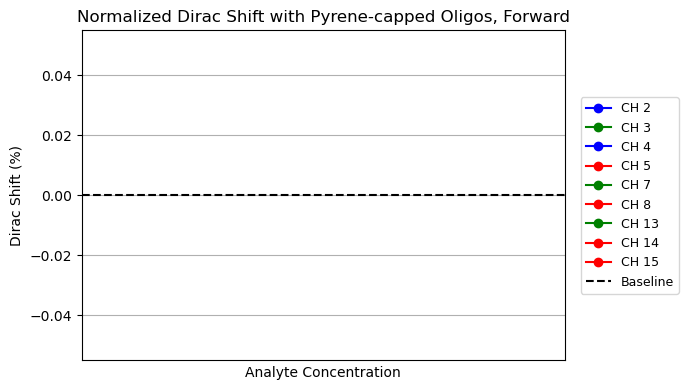

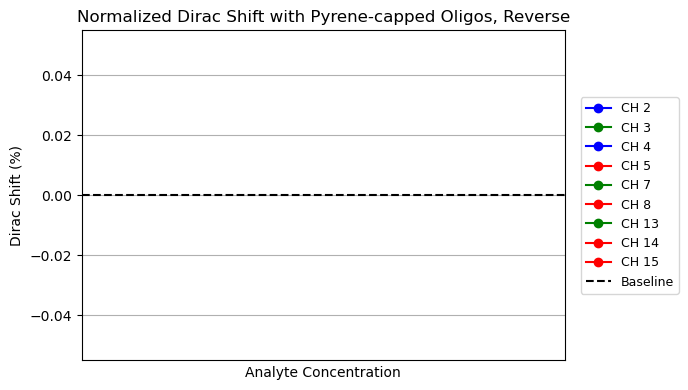

In [9]:
folder_path = "../data_pcb_smu/" + "2026-06-22 w7d16 dirac-tracking pbase-oligo pos-neg-ctrl/"
channels_to_omit = [0,1,6,9,10,11,12]
channel_colors = ['blue', 'red', 'blue', 'green', 'blue', 'red', 'blue', 'green', 'red', 'green', 'green', 'red', 'green', 'green', 'red', 'red']
func_steps = ["Initial", "DDT", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


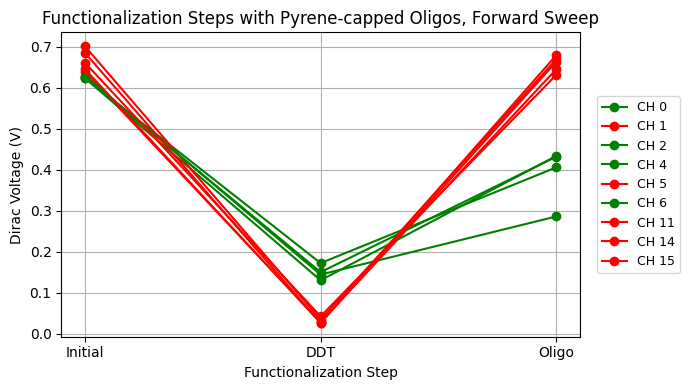

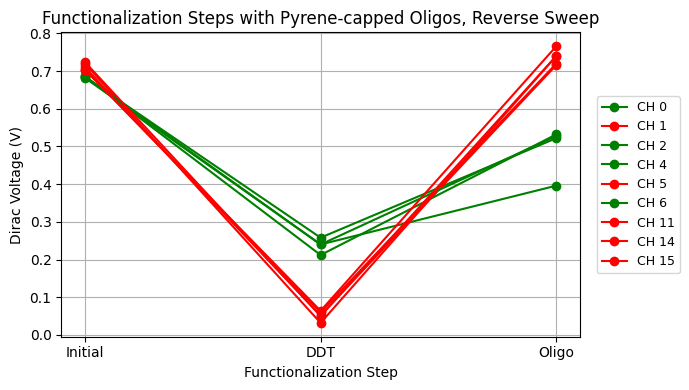

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


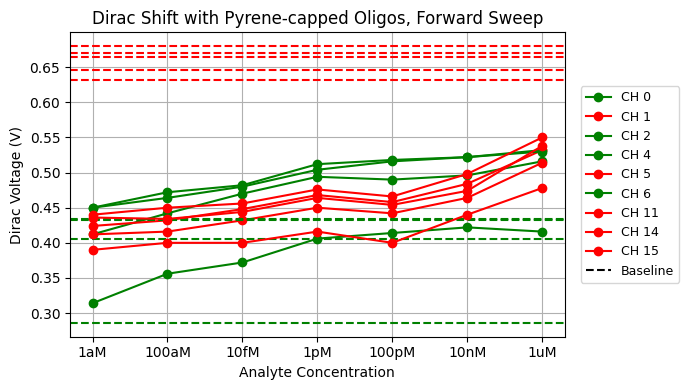

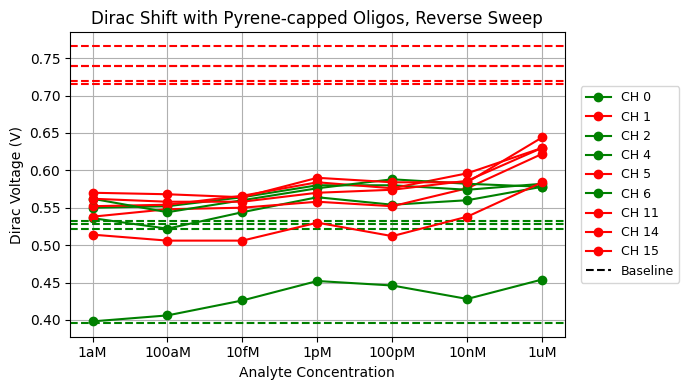

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


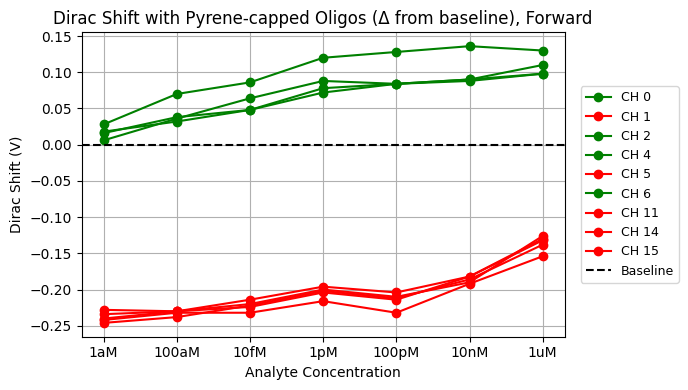

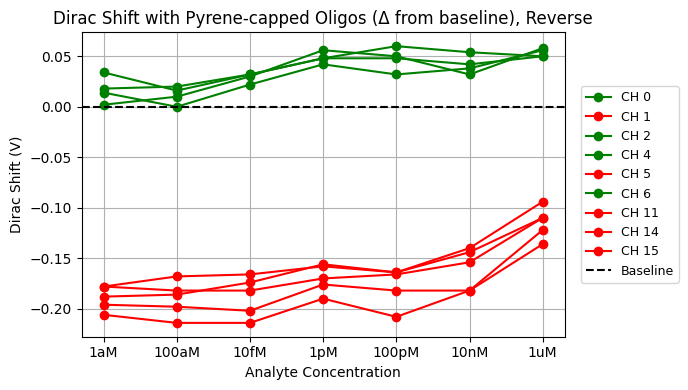

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


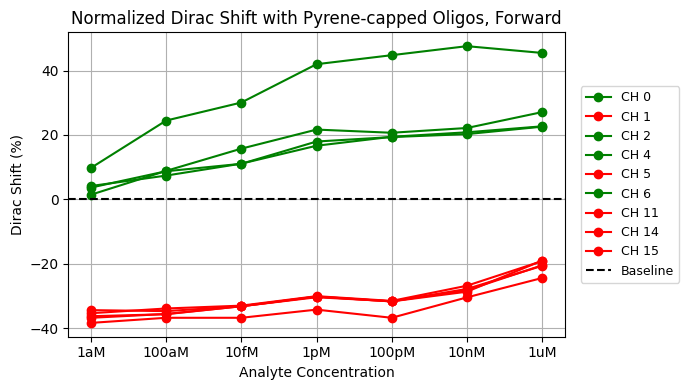

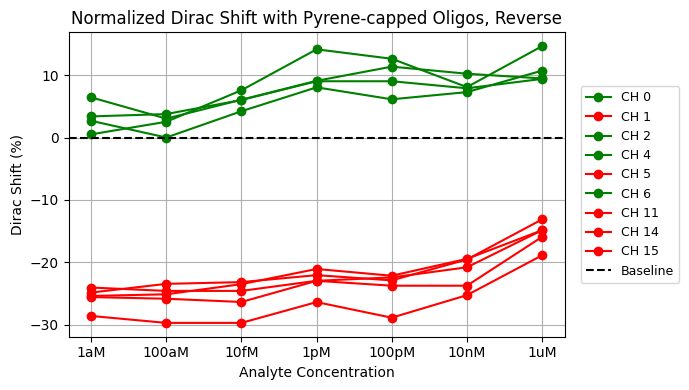

In [5]:
folder_path = "../data_pcb_smu/" + "2026-03-17 w1d13 dirac-tracking pyrene-capped pos-neg-ctrl/"
channels_to_omit = [3, 7, 9, 8, 10, 12, 13] # [1, 5, 8, 11, 14, 15]


# (1): NONE
# (2): Neg ctrl, scrambled oligo
# (3): Pos ctrl, complement oligo
# (4): NONE


# The respective channels are:
# (1): NONE
# (2): 1, 5, 8, 11, 14, 15
# (3): 0, 2, 4, 6
# (4): 3, 7, 9, 10, 12, 13

channel_colors = ['green', 'red', 'green', 'black', 'green', 'red', 'green', 'black', 'red', 'black', 'black', 'red', 'black', 'black', 'red', 'red']
func_steps = ["Initial", "DDT", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w1d06-id.csv
func2-w1d06-oligo.csv


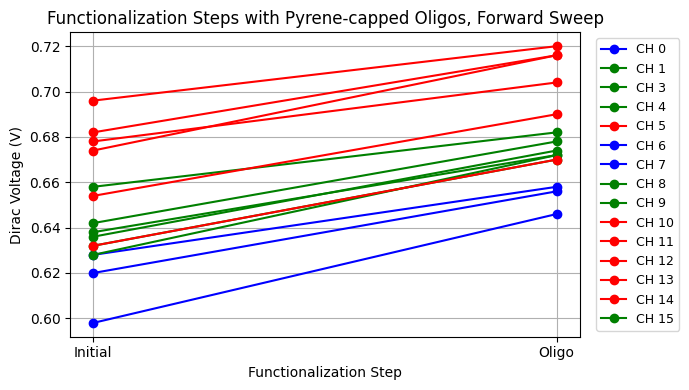

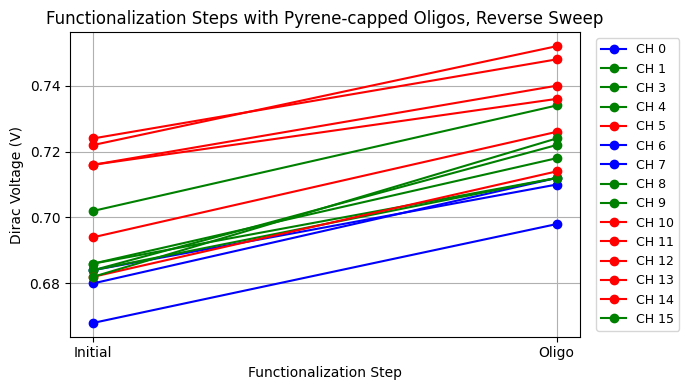

func1-w1d06-id.csv
func2-w1d06-oligo.csv


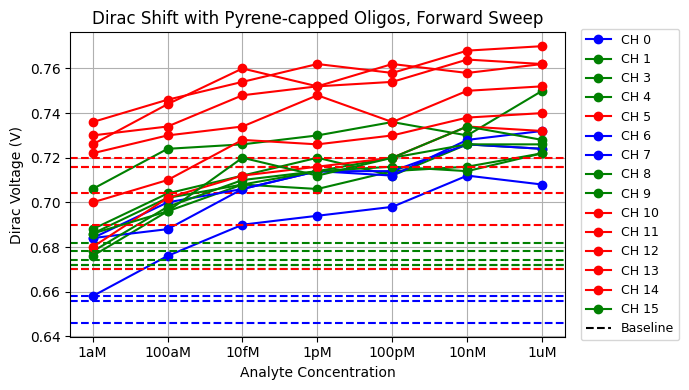

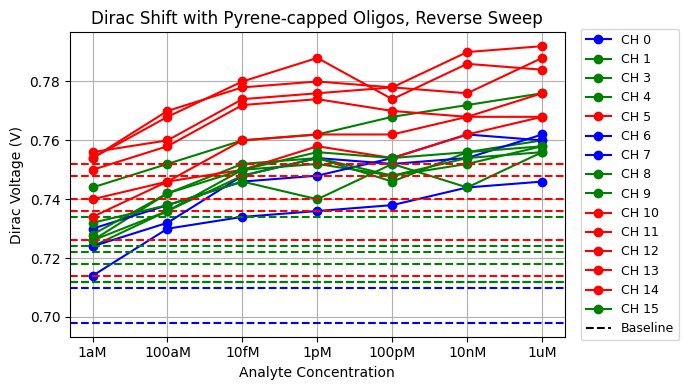

func1-w1d06-id.csv
func2-w1d06-oligo.csv


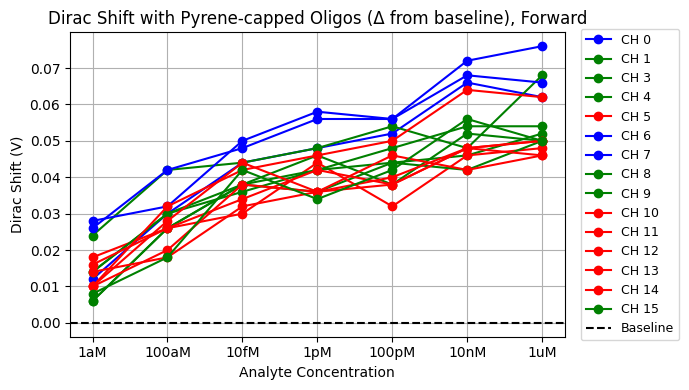

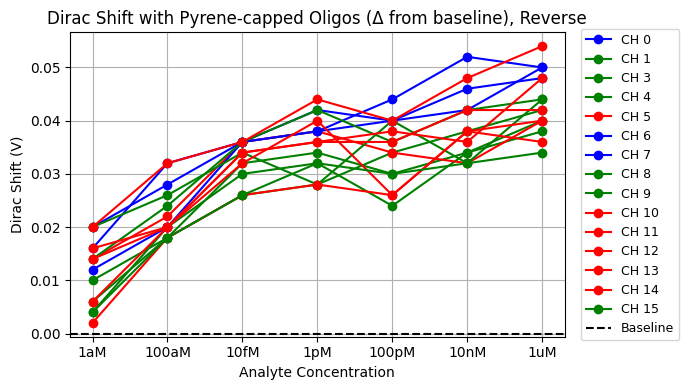

func1-w1d06-id.csv
func2-w1d06-oligo.csv


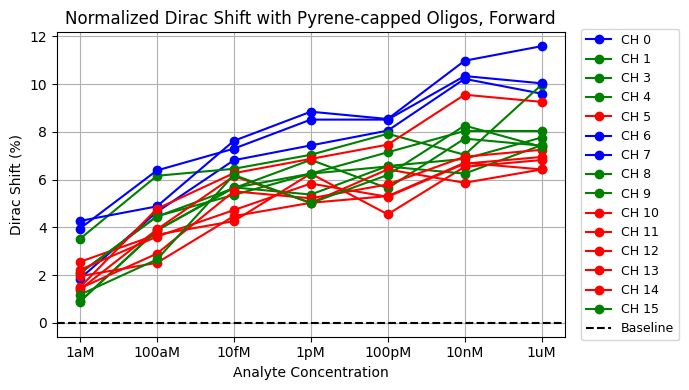

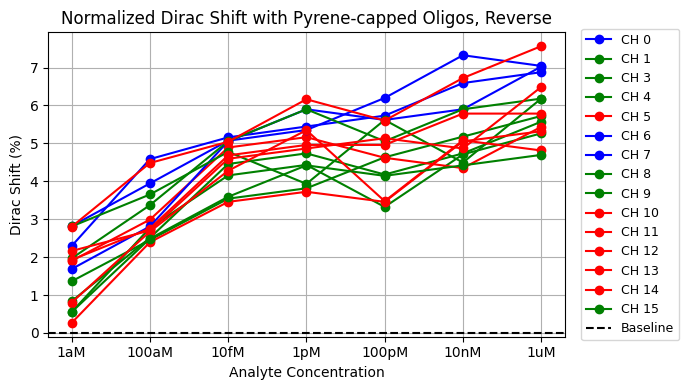

In [6]:
folder_path = "../data_pcb_smu/" + "2026-03-18 w1d06 dirac-tracking pyrene-capped pos-neg-ctrl/"
channels_to_omit = [2]
channel_colors = ['blue', 'green', 'blue', 'green', 'green', 'red', 'blue', 'blue', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'green'] 
func_steps = ["Initial", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


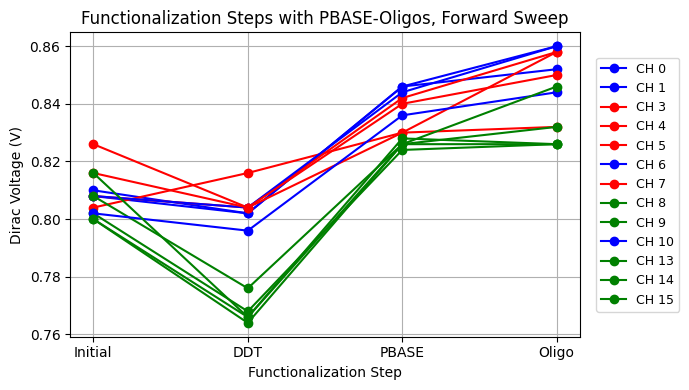

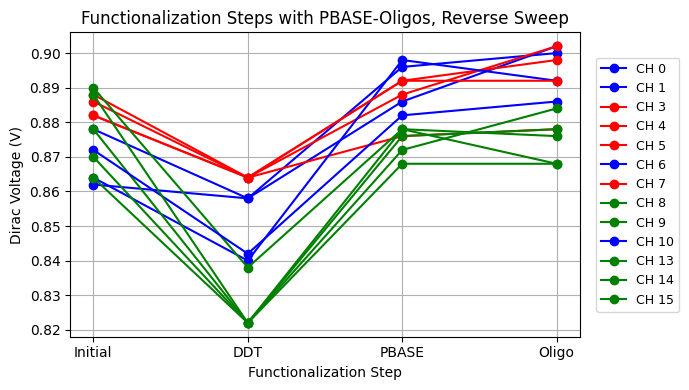

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


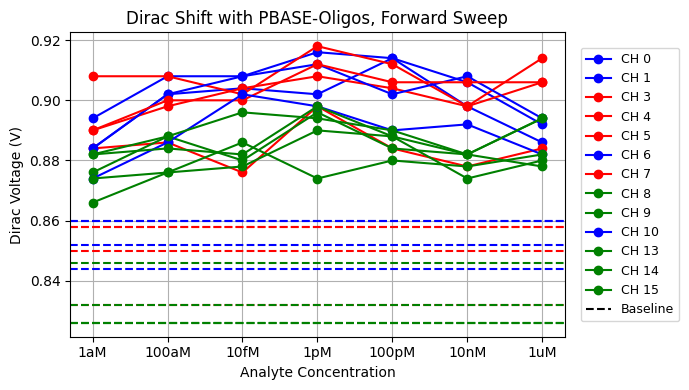

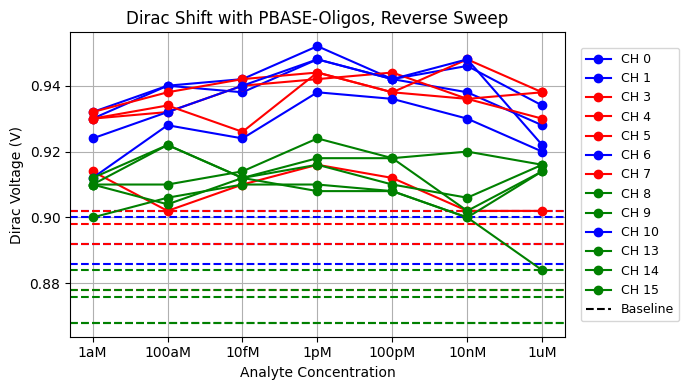

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


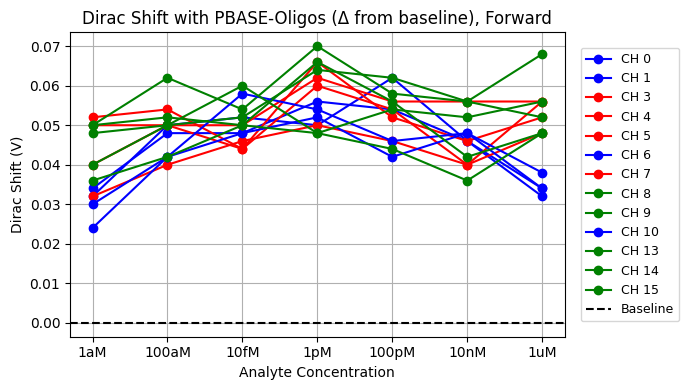

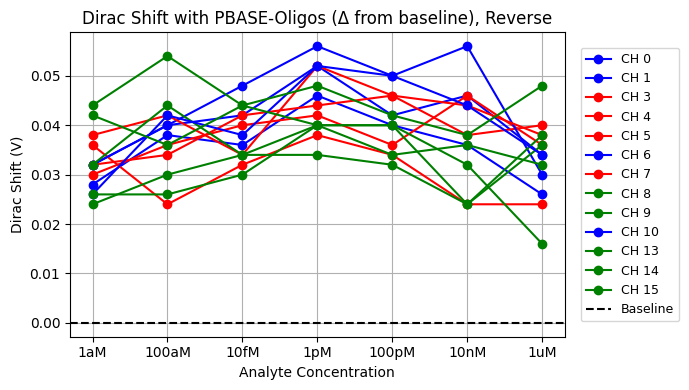

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


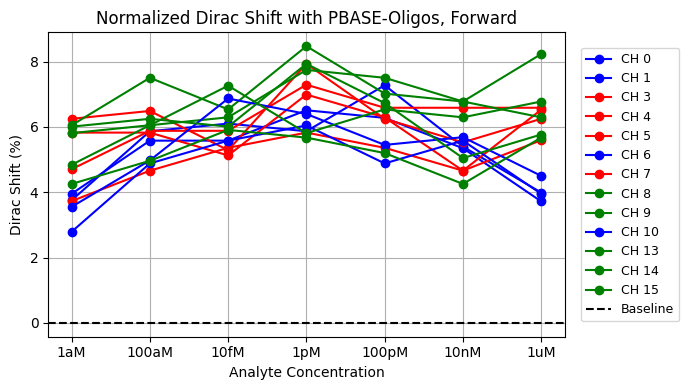

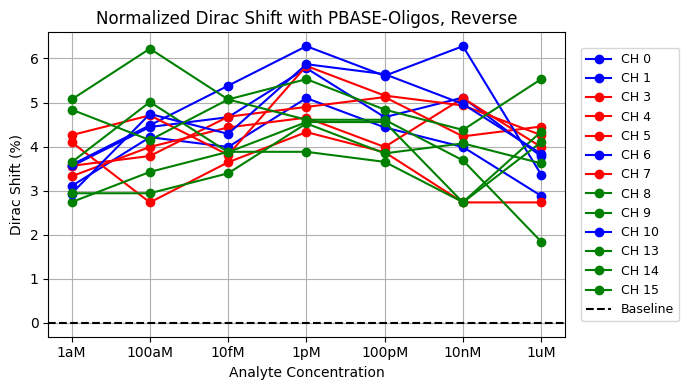

In [7]:
folder_path = "../data_pcb_smu/" + "2026-03-31 w2d13 dirac-tracking pbase-oligo pos-neg-ctrl/"
channels_to_omit = [11, 2, 12]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


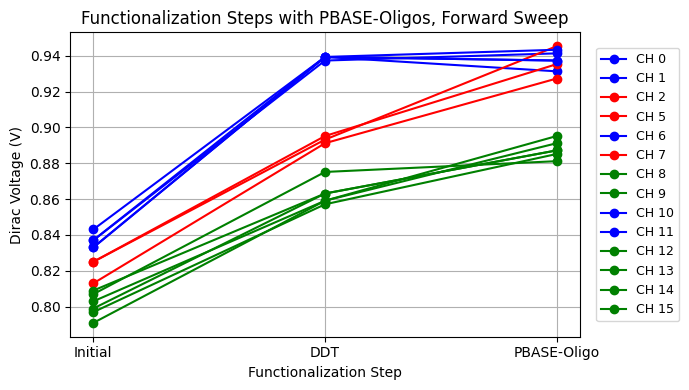

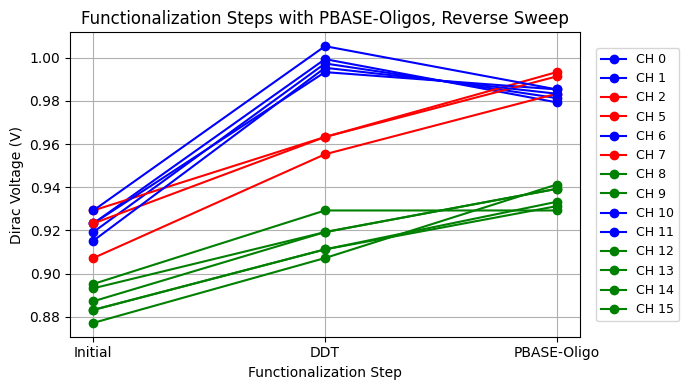

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


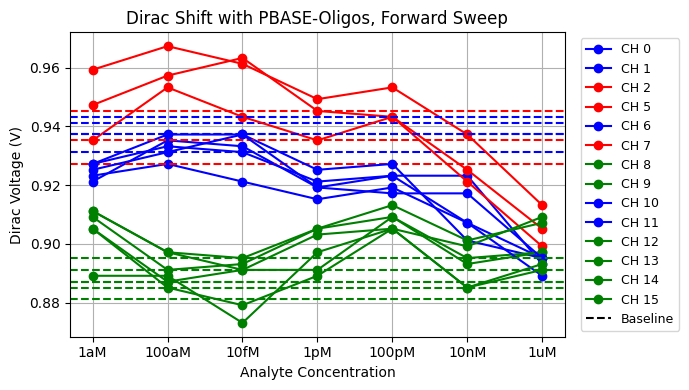

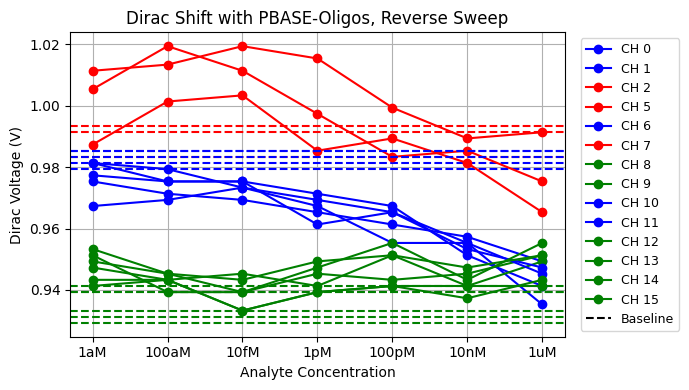

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


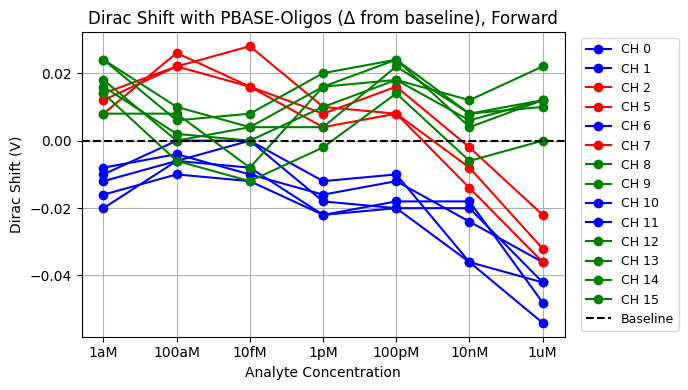

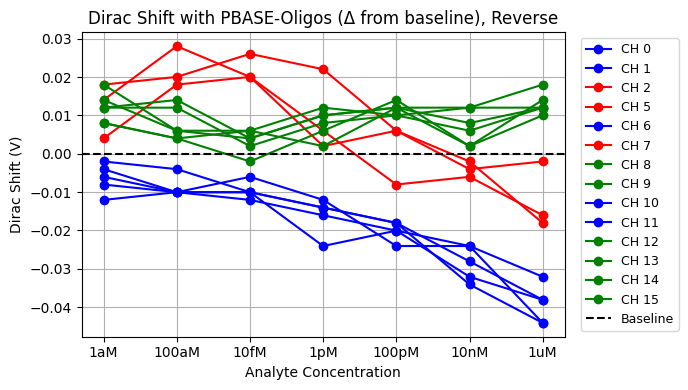

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


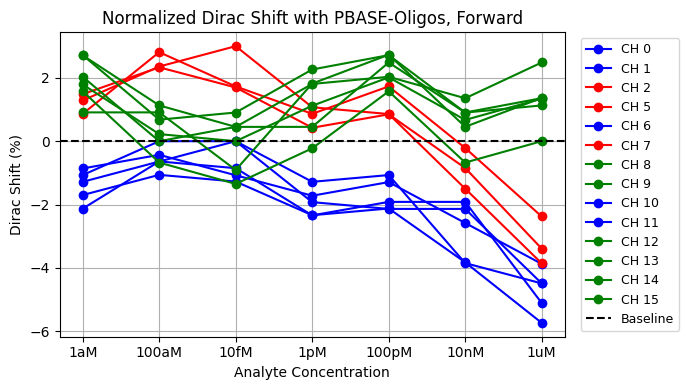

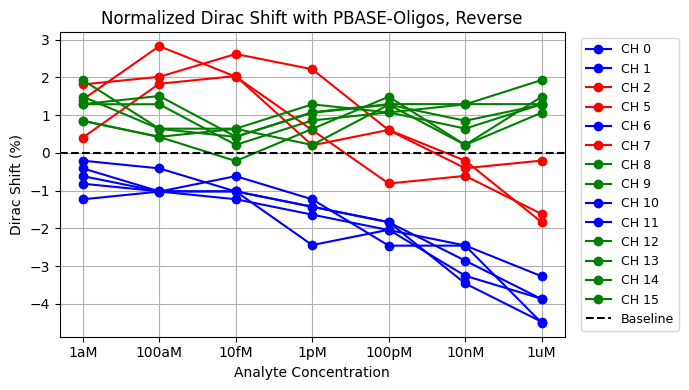

In [8]:
folder_path = "../data_pcb_smu/" + '2026-04-07 w2d16 dirac-tracking pbase-oligo pos-neg-ctrl/'
channels_to_omit = [3, 4]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE-Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


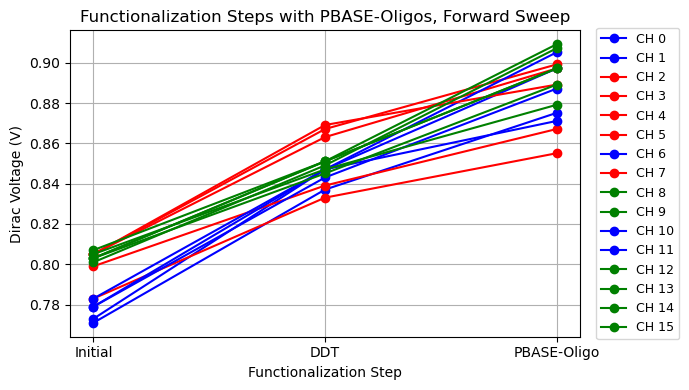

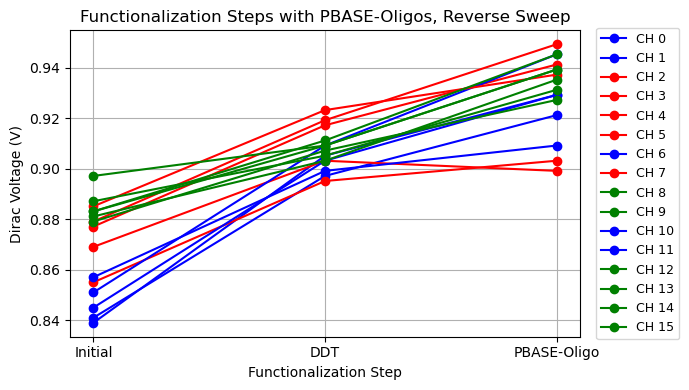

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


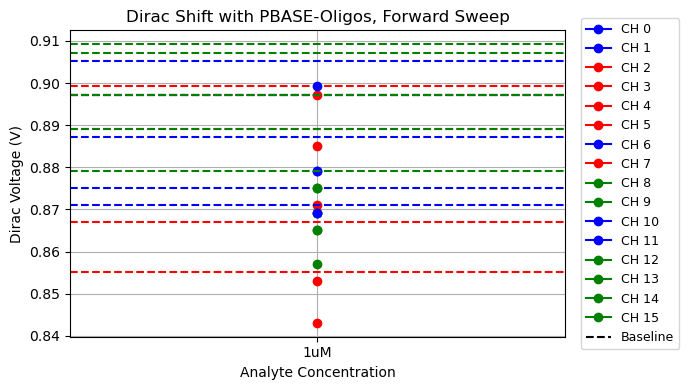

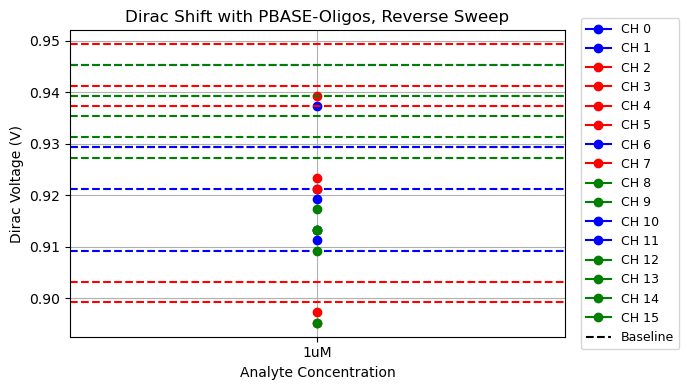

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


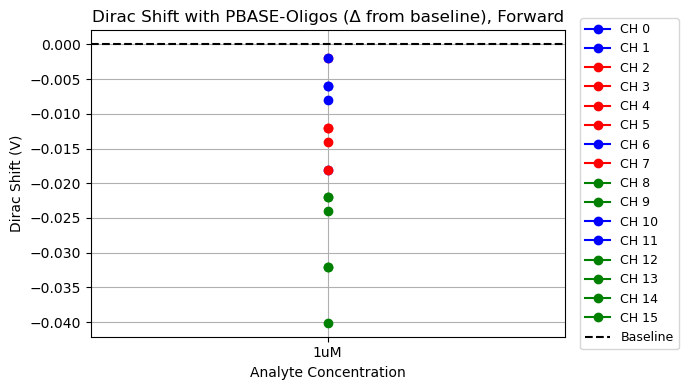

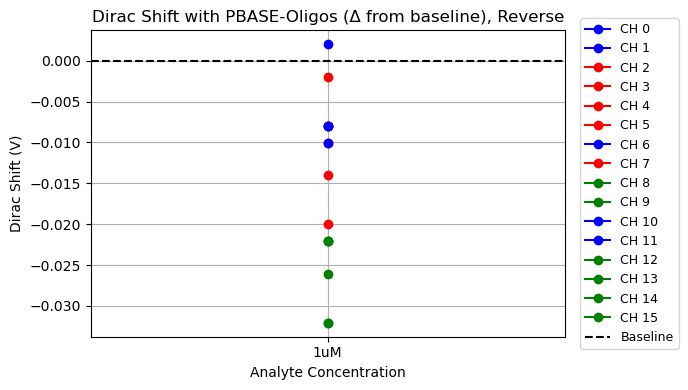

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


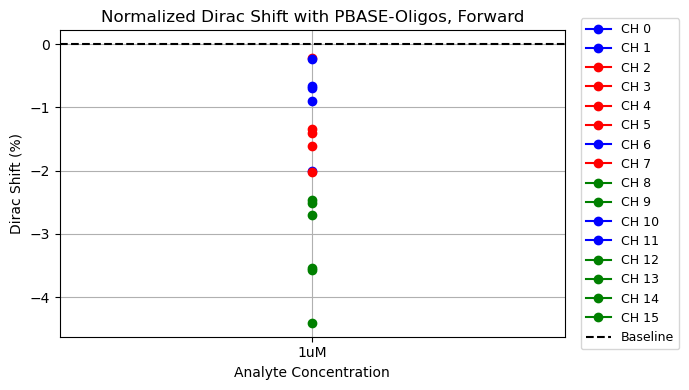

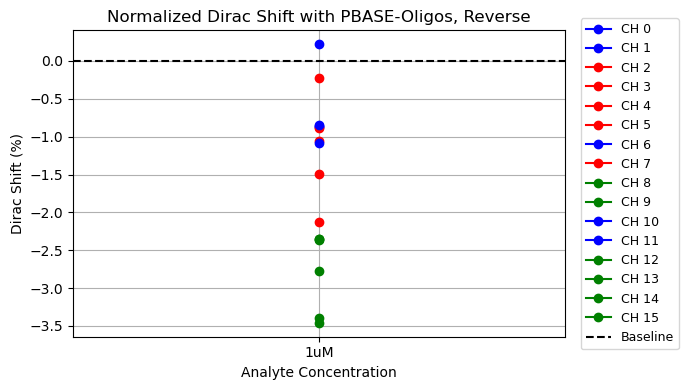

In [10]:
folder_path = "../data_pcb_smu/" + '2026-04-16 w2d15 dirac-tracking pbase-oligo pos-neg-ctrl/'

channels_to_omit = []

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7} 
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE-Oligo"]
analyte_steps = ["1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


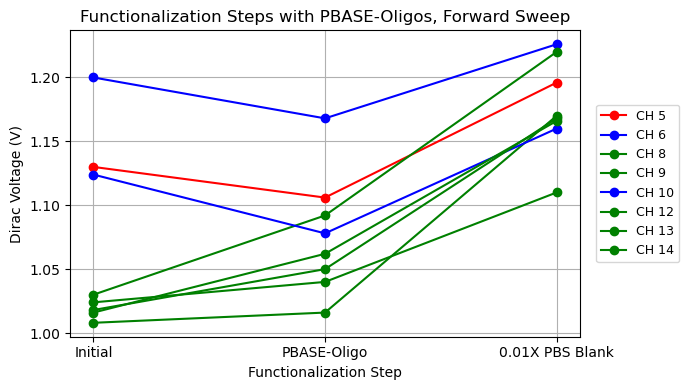

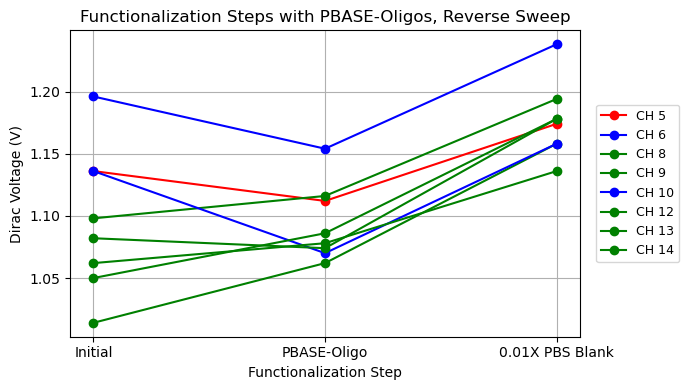

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


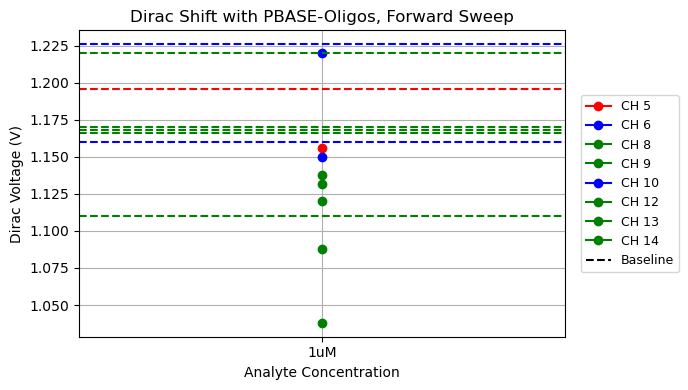

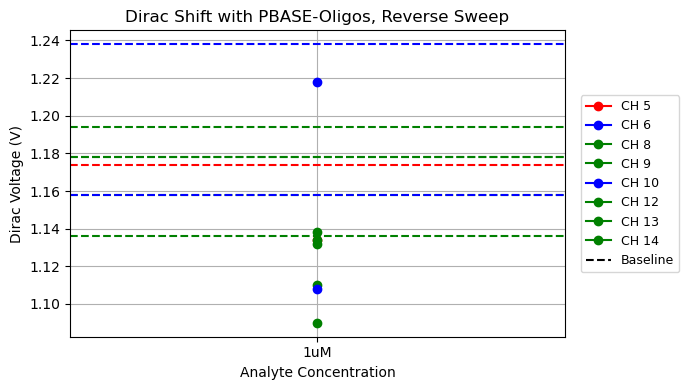

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


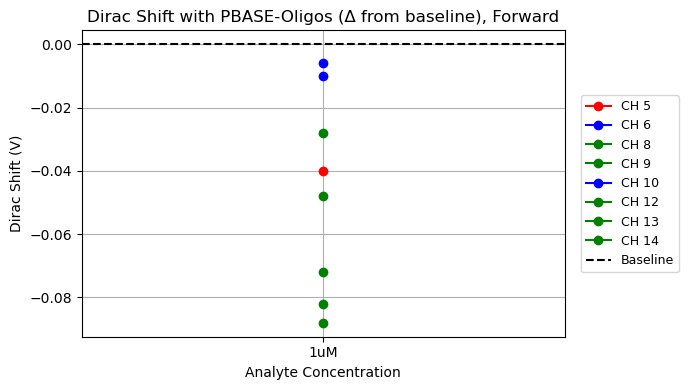

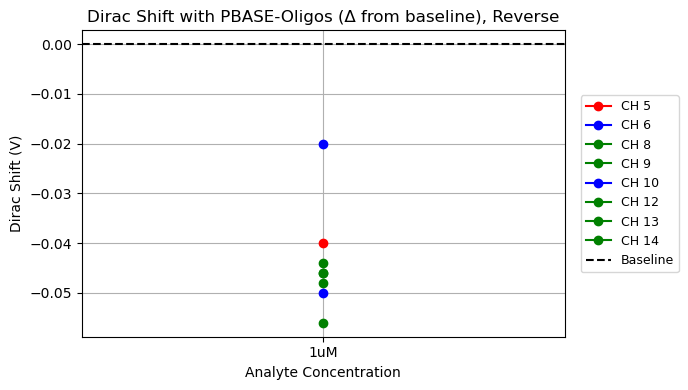

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


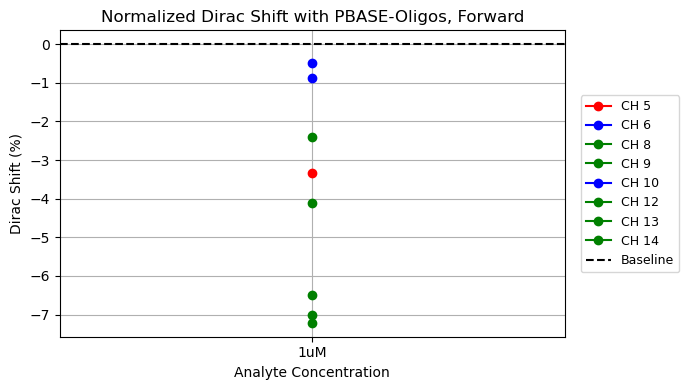

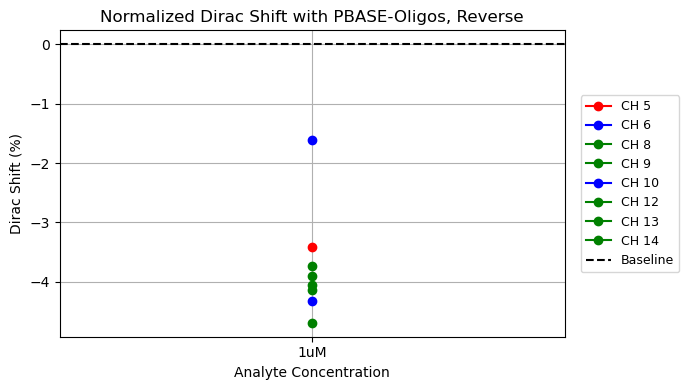

In [26]:
folder_path = "../data_pcb_smu/" + '2026-05-13 w3d6 dirac-tracking pbase-oligo pos-neg-ctrl/'

channels_to_omit = [0,1,2,3,4,7,11,15]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7} 
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "PBASE-Oligo", "0.01X PBS Blank"]
analyte_steps = ["1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w7d16-initial.csv
func2-w7d16-ddt.csv
func3-w7d16-pbase-oligo.csv
func4-w7d16-0.01x.csv


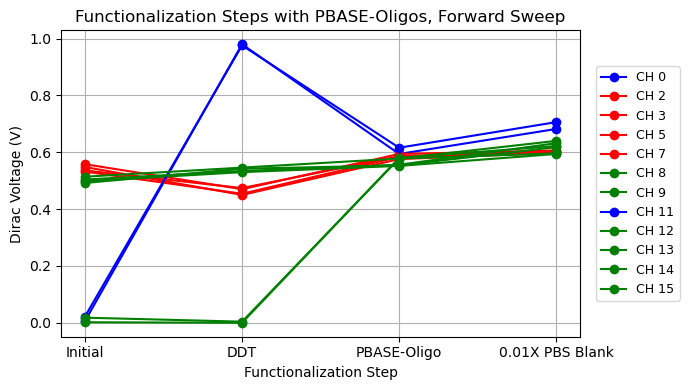

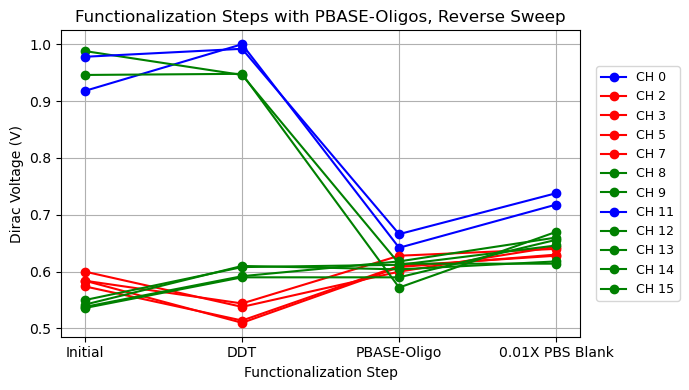

func1-w7d16-initial.csv
func2-w7d16-ddt.csv
func3-w7d16-pbase-oligo.csv
func4-w7d16-0.01x.csv


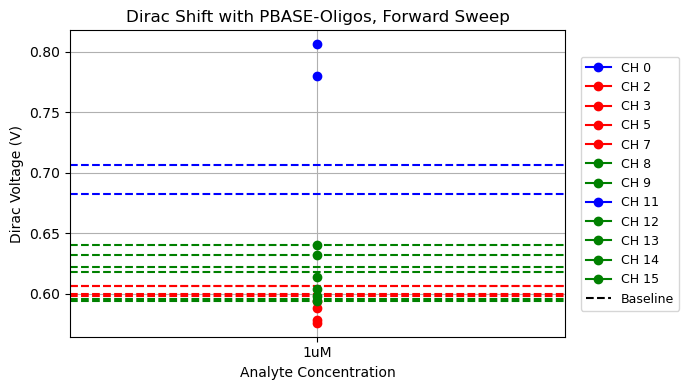

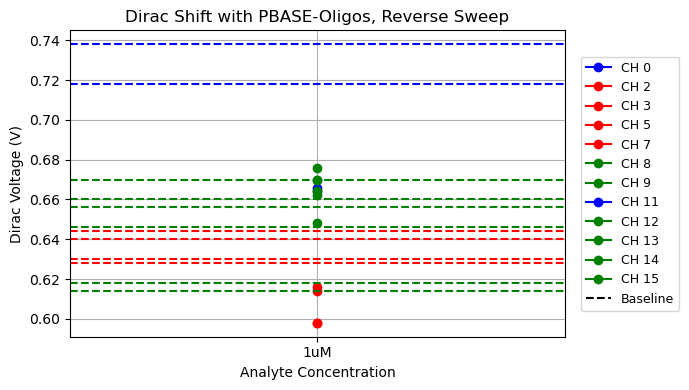

func1-w7d16-initial.csv
func2-w7d16-ddt.csv
func3-w7d16-pbase-oligo.csv
func4-w7d16-0.01x.csv


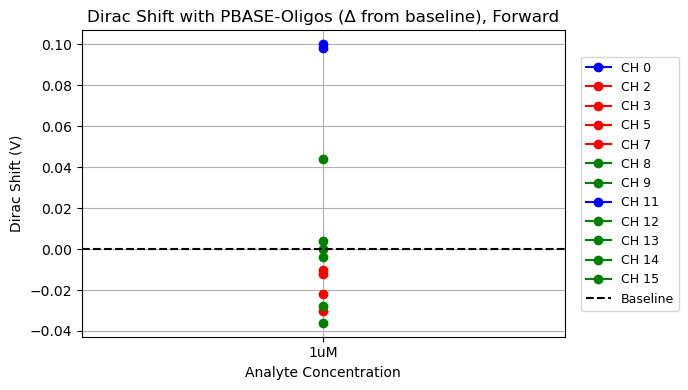

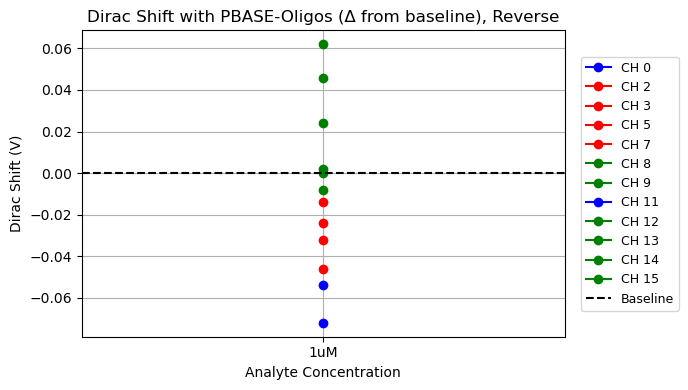

func1-w7d16-initial.csv
func2-w7d16-ddt.csv
func3-w7d16-pbase-oligo.csv
func4-w7d16-0.01x.csv


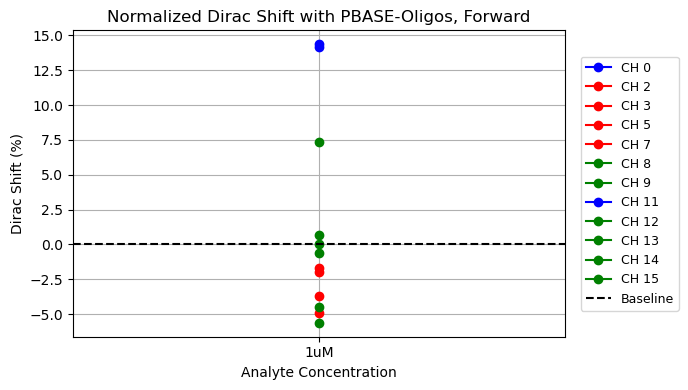

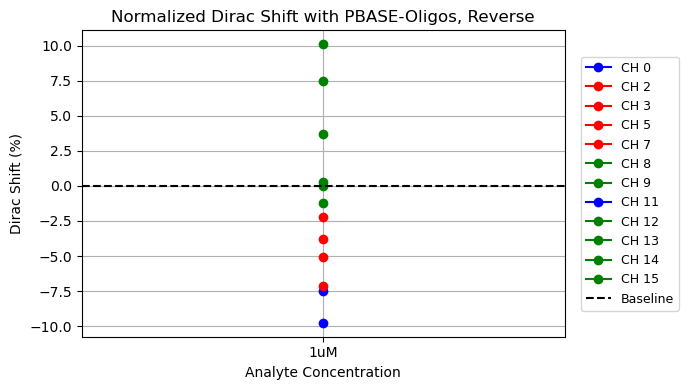

In [47]:
folder_path = "../data_pcb_smu/" + '2026-06-22 w7d16 dirac-tracking pbase-oligo pos-neg-ctrl/'

channels_to_omit = [1,4,6,10]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7} 
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial","DDT", "PBASE-Oligo", "0.01X PBS Blank"]
analyte_steps = ["1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()